# Final Assignment: Database Management Tools in Python

##### Name: Sagar Kumar
##### Matriculation No.: 30000402
##### Course: MDET-105-Data Base Management Tools in Python
##### Semester: Fall 2025
##### Instructor: Atit Bashyal

## Part I: Data Structures & Algorithms (15 Points)

### A. Node-Based Implementation
#### 1. Linked Nodes

In [70]:
# double linked node class to be used in stack
class DoublyLinkedNode:
    def __init__(self, value):
        self.value = value
        self.prev = None
        self.next = None

# stack class implementation with methods: pop, push, peek, is_empty, get_size
class Stack:
    def __init__(self):
        self.top = None
        self.size = 0

    def push(self, value):
        new_node = DoublyLinkedNode(value)
        new_node.next = self.top
        if self.top:
            self.top.prev = new_node
        self.top = new_node
        self.size += 1

    def pop(self):
        if not self.top:
            raise IndexError("pop from empty stack")
        value = self.top.value
        self.top = self.top.next
        if self.top:
            self.top.prev = None
        self.size -= 1
        return value

    def peek(self):
        if not self.top:
            raise IndexError("peek from empty stack")
        return self.top.value

    def is_empty(self):
        return self.size == 0
    
    def get_size(self):
        return self.size

# Queue class implementation:
# general idea is use two stacks: stack_in, stack_out
# the process of moving items from stack_in to stack_out reverses the stack
# therefore the pop operation acts just like a queue
class Queue:
    def __init__(self):
        self.stack_in = Stack()
        self.stack_out = Stack()

    def enqueue(self, value):
        self.stack_in.push(value)

    def dequeue(self):
        if self.stack_out.is_empty():
            while not self.stack_in.is_empty():
                self.stack_out.push(self.stack_in.pop())
        if self.stack_out.is_empty():
            raise IndexError("dequeue from empty queue")
        return self.stack_out.pop()

    def peek(self):
        if self.stack_out.is_empty():
            while not self.stack_in.is_empty():
                self.stack_out.push(self.stack_in.pop())
        if self.stack_out.is_empty():
            return "Queue is empty"
        return self.stack_out.peek()

# test code: 
testQueue = Queue()

testQueue.enqueue(1)
testQueue.enqueue(2)
testQueue.enqueue(3)

print(testQueue.peek())     # 1
print(testQueue.dequeue())  # 1

print(testQueue.peek())     # 2
print(testQueue.dequeue())  # 2

print(testQueue.peek())     # 3
print(testQueue.dequeue())  # 3

print(testQueue.peek())     # Queue is empty

1
1
2
2
3
3
Queue is empty


#### 2. Hash Tables with Binary Search Trees (BST)

In [71]:
class Node:
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.left_child = None
        self.right_child = None

# general idea: hash keys to buckets and store colliding keys in a BST
# binary tree means each node has at most two children
class BinarySearchTree:
    def __init__(self):
        self.root_node = None

    def insert(self, key, value):
        n = Node(key, value)
        if self.root_node is None:
            self.root_node = n
            return
        cur = self.root_node
        while True:
            if key == cur.key: # update case
                cur.value = value      
                return
            elif key < cur.key:
                if cur.left_child is None:
                    cur.left_child = n
                    return
                cur = cur.left_child
            else:
                if cur.right_child is None:
                    cur.right_child = n
                    return
                cur = cur.right_child

    def search(self, key):
        cur = self.root_node
        while cur:
            if key == cur.key:
                return cur.value
            cur = cur.left_child if key < cur.key else cur.right_child
        return None

    def get_node_with_parent(self, key):
        parent, cur = None, self.root_node
        while cur:
            if key == cur.key:
                return parent, cur
            parent = cur
            cur = cur.left_child if key < cur.key else cur.right_child
        return None, None

    # delete a key from the BST using standard cases and in-order successor replacement
    def remove(self, key):
        parent, node = self.get_node_with_parent(key)
        if node is None:
            return False

        # get children count
        children = (1 if node.left_child else 0) + (1 if node.right_child else 0)

        # 0 children
        if children == 0:
            if parent is None:
                self.root_node = None
            elif parent.left_child is node:
                parent.left_child = None
            else:
                parent.right_child = None
            return True

        # 1 children
        if children == 1:
            child = node.left_child if node.left_child else node.right_child
            if parent is None:
                self.root_node = child
            elif parent.left_child is node:
                parent.left_child = child
            else:
                parent.right_child = child
            return True

        # 2 children 
        parent_succ, succ = node, node.right_child
        while succ.left_child:
            parent_succ, succ = succ, succ.left_child
        node.key, node.value = succ.key, succ.value
        if parent_succ.left_child is succ:
            parent_succ.left_child = succ.right_child
        else:
            parent_succ.right_child = succ.right_child
        return True

# hash table where each bucket uses a binary search tree to resolve collisions
class HashTable:
    def __init__(self, capacity=8): # by default, capacity is 8
        self.capacity = max(1, capacity)
        self.buckets = [BinarySearchTree() for _ in range(self.capacity)]
        self.size = 0

    def _index(self, key):
        return hash(key) % self.capacity

    # check if the key already exists in the bucket before inserting
    def insert(self, key, value):
        idx = self._index(key)
        existed = self.buckets[idx].search(key) is not None
        self.buckets[idx].insert(key, value)
        if not existed:
            self.size += 1

    def search(self, key):
        idx = self._index(key)
        return self.buckets[idx].search(key)

    def delete(self, key):
        idx = self._index(key)
        removed = self.buckets[idx].remove(key)
        if removed:
            self.size -= 1
        return removed


# basic tests: 
# 1. insert key-value pairs
# 2. update existing key
# 3. search for values that exist and dont exist
# 4. delete keys
# 5. output size

if __name__ == "__main__":
    fruit_basket = HashTable(capacity=4)

    # 1
    fruit_basket.insert("apple", 6)
    fruit_basket.insert("pineapple", 1)
    fruit_basket.insert("orange", 4)

    # 2
    fruit_basket.insert("pineapple", 2)  # update number of pineapples 1->2

    # 3
    print(fruit_basket.search("apple")) # 6
    print(fruit_basket.search("pineapple")) # 2
    print(fruit_basket.search("kiwi")) # None

    # 4
    print(fruit_basket.delete("orange")) # True
    print(fruit_basket.delete("kiwi")) # False
    print(fruit_basket.search("orange")) # None

    # 5
    print("size:", fruit_basket.size) # 2

6
2
None
True
False
None
size: 2


#### 3. Graph Implementation

In [72]:
# node with adjacency list representation
class Node:
    def __init__(self, value):
        self.value = value
        self.neighbors = []

# undirected graph with BFS and DFS usage
class Graph:
    def __init__(self):
        self.nodes = {}      

    def add_node(self, value):
        if value not in self.nodes:
            self.nodes[value] = Node(value)

    def add_edge(self, a, b):
        self.add_node(a)
        self.add_node(b)
        self.nodes[a].neighbors.append(self.nodes[b])
        self.nodes[b].neighbors.append(self.nodes[a])  

    # depth first search (using recursion)
    def dfs(self, start):
        visited = set()

        def dfs_recursive(value):
            if value in visited: # base case
                return
            visited.add(value)
            print(value, end=" ")
            for n in self.nodes[value].neighbors:
                dfs_recursive(n.value)

        dfs_recursive(start)
        print()

    # breadth first search (using queue)
    def bfs(self, start):
        visited = {start}
        queue = [start]
        while queue:
            v = queue.pop(0)
            print(v, end=" ")
            for n in self.nodes[v].neighbors:
                if n.value not in visited:
                    visited.add(n.value)
                    queue.append(n.value)
        print()


# Example
g = Graph()
g.add_edge("A", "B")
g.add_edge("A", "C")
g.add_edge("B", "D")
g.add_edge("C", "E")

# start from Node A
print("Depth First Search from A:")
g.dfs("A")
print("Breadth First Search from A:")
g.bfs("A")

# start from Node E
print("Depth First Search from E:")
g.dfs("E")
print("Breadth First Search from E:")
g.bfs("E")

Depth First Search from A:
A B D C E 
Breadth First Search from A:
A B C D E 
Depth First Search from E:
E C A B D 
Breadth First Search from E:
E C A B D 


## 2. Part II: Databases, Ingestion & Analytics (25 Points)
### 2.1 Data and Database Engineering

#### 2.1.1 Choosing a Dataset

Real World Source: For the purposes of this project, I have chosen the "Netflix Movies and TV Shows" dataset from Kaggle. This dataset license is "CC0: Public Domain" and therefore available for public use.

Structure: The dataset used will be highly structured and in a tabular manner, therefore the best type of data to store this is a document database. This structured format simplifies querying and indexing the data into analytics workflows.

Volume and Velocity: The dataset itself has moderate volume. There are 12 columns and around 8800 data entries or rows. Which means that a document database system can handle these datasets effectively. Since the data does not update frequently, batch ingestion processes are sufficient and no streaming architecture is required.

Relationships: As for the contents of the dataset, it includes a structured list of TV shows and Movies from Netflix as well as information about the cast, director, release year etc. It also contains meaningful relationships, such as between movies, genres, countries, and directors. These relationships will enable richer analytical queries such as genre breakdowns, country production trends etc.

Link to Kaggle Dataset: https://www.kaggle.com/datasets/shivamb/netflix-shows?resource=download

#### 2.1.2 Understanding the Data: Real-World Origins and Characteristics

Real World System: The dataset originates from Netflix’s catalog of movies and TV shows, representing real-world media production and distribution processes. In our case, it is being used in an academic manner as a representative example of a structured, industry-grade dataset to demonstrate database design, ingestion workflows and analytical processing.

1. Origin: The data is generated by Netflix’s internal content management system (CMS), which records metadata about every title on the platform. This implies the data is highly structured and curated rather than noisy or sensor-based. 
2. Frequency: The dataset is updated whenever Netflix adds or removes content—typically daily or weekly rather than real-time. This means ingestion does not require streaming pipelines, only periodic batch updates.
3. Volume: The dataset has around 8800 rows and 12 columns. The dataset is moderate in size and far below big data thresholds. This indicates that a document database is sufficient.
4. Type and Richness of Relationships: The dataset contains meaningful relationships between titles, genres, countries, directors, and cast members. This suggests that relational schemas or document databases with foreign keys or many-to-many relationships are useful for organizing the data for our context.


#### 2.1.3 Database Selection: Document Database

We will store the netflix titles data as a document database, i.e. flexible JSON documents. Each netflix title in the database will be represented as a single document containing fields of "title", "director", "type", "cast", "release_year" and more. The benefit of using a document database is that some netflix titles are missing values like director, so the JSON structure can easily adapt to this case. 

*Source & Structure*: The Netflix dataset comes from a real-world content catalog where each movie and show has different types of information and not every title includes the same details. This makes the data naturally uneven and flexible, making a document database the right choice.
*Storage*: A document database stores each title as a flexible JSON document, making it easy to handle lists and nested data. It avoids complicated joins and matches the natural shape of the dataset, making storage simpler and more scalable. In addition, The row key/identifier (in our case the “show_id” field) becomes the unique document ID, which allows fast lookups and efficient indexing in a document store.

The following is an exmaple of a single document: 

In [73]:
{
  "show_id": "9123193192",
  "title": "Stranger Things",
  "type": "TV Show",
  "director": "Duffer Brothers",
  "cast": [
    "Winona Ryder",
    "David Harbour",
    "Millie Bobby Brown"
  ],
  "country": ["United States"],
  "date_added": "July 15, 2016",
  "release_year": 2016,
  "rating": "TV-14",
  "duration": "3 Seasons",
  "listed_in": ["Sci-Fi", "Drama", "Horror"],
  "description": "When a young boy disappears, a small town uncovers a mystery involving secret experiments and supernatural forces."
}

{'show_id': '9123193192',
 'title': 'Stranger Things',
 'type': 'TV Show',
 'director': 'Duffer Brothers',
 'cast': ['Winona Ryder', 'David Harbour', 'Millie Bobby Brown'],
 'country': ['United States'],
 'date_added': 'July 15, 2016',
 'release_year': 2016,
 'rating': 'TV-14',
 'duration': '3 Seasons',
 'listed_in': ['Sci-Fi', 'Drama', 'Horror'],
 'description': 'When a young boy disappears, a small town uncovers a mystery involving secret experiments and supernatural forces.'}

#### 2.1.4 Designing the Ingestion Pipeline: Connecting the Real World to your Database

Since we have chosen a document database, our ingestion pipeline will preserve the semi-structured shape of the dataset. The volume of the dataset is moderate at around 8000 titles and the velocity is quite low at occasional updates rather than real-time streamed data. Therefore, a batch-oriented ELT (Extract, Load, Transform) pipeline will work for our scenario.

##### Extract:

The extraction stage is straight-forward because the real-world source already comes as a CSV file with semi-structured fields. The low velocity means extraction can happen occasionally in batches rather than as a real-time stream. The structure of the raw data influences this step because we only need to extract the fields as they are, without flattening or normalizing them as required in relational databases.

##### Load:

We will perform loading through document writes (insert_one() or insert_many()), which store each title as a full JSON document. The flexible schema of MongoDB allows us to load the raw records directly without enforcing strict column types. Because the dataset size is relatively small, batch loading is efficient. 

##### Transform:

We will perform transformations such as converting lists, parsing dates, or cleaning missing values. The structure of the data benefits from document-level transformations, such as updating specific fields inside each document. The constraints of using a document database allow us to transform data incrementally without breaking the consistency of other documents as well. 

### 2.2 Analytics and Visualization
#### 2.2.1 Writing Insertion, Retrieval, and Analytical Queries

For our document database, we will use simple Python-style pseudocode to show how insertion and retrieval would work with our dataset. Because each title is stored as a single JSON document, inserting data becomes as easy as adding one full record at a time. Retrieval is also easy because queries directly match the natural shape of the documents. A basic retrieval might filter all documents where "type": "Movie" or search for titles that contain "Germany" in the countries list. In our case, the database is named "netflix_titles".

In a real-world scenario, we will use the Python MongoDB driver PyMongo to connect and interact with the netflix_titles database. With PyMongo, we can create a MongoClient, select the database and collection, and then call methods like .insert_one(), .insert_many(), and .find() exactly as in our pseudocode. More advanced analysis can be done using MongoDB’s aggregation pipelines and the query results can be converted into pandas DataFrames for plotting with matplotlib.

##### Database Insertion:

For insertion, we first need to create a sample document, then we insert it into the databse using .insert_one() for inserting a single document and .insert_all() to bulk insert multiple documents at once using a list. The pseudo-code is as follows: 

stranger_things_title = {
  "show_id": "9123193192",
  "title": "Stranger Things",
  "type": "TV Show",
  "director": "Duffer Brothers",
  "cast": [
    "Winona Ryder",
    "David Harbour",
    "Millie Bobby Brown"
  ],
  "country": ["United States"],
  "date_added": "July 15, 2016",
  "release_year": 2016,
  "rating": "TV-14",
  "duration": "3 Seasons",
  "listed_in": ["Sci-Fi", "Drama", "Horror"],
  "description": "When a young boy disappears, a small town uncovers a mystery involving secret experiments and supernatural forces."
}

db.netflix_titles.insert_one(stranger_things_title)

db.netflix_titles.insert_many([stranger_things_title, ...])

##### Database Retrieval:

For retrieval, we can use simple queries that match fields inside each document. Since the data is stored as JSON, we can directly filter by keys such as type, country, or release_year. For example, to get all movies, we check {"type": "Movie"}. To find titles related to Germany, we search the country list. Below are some examples:

Get all movies: 

* movies = db.netflix_titles.find({ "type": "Movie" })

Get movies produced in Germany:

* german_titles = db.netflix_titles.find({ "country": "Germany" })

Get all titles added after and including 2020: 

* recent_titles = db.netflix_titles.find({
    "release_year": { "$gte": 2020 }
})

Get all TV Shows that fall under more than 1 genre:

* multi_genre_shows = db.netflix_titles.find({
“type”: “TV Show”,
“$expr”: { “$gt”: [ { “$size”: “$listed_in” }, 1 ] }
})


#### 2.2.2 Data Loading and Cleaning in Python

We import the data using the read_csv() function and then replace all the missing values in the dataset with “Unknown”. This is helpful because missing values can lead to inaccurate or incomplete analysis. Especially when performing aggregations or visualizations. By filling them with a placeholder like "Unknown", we ensure that no records are excluded during data processing and that all rows remain consistent. Also, we transform some of our data types so that they can be more easily worked with. 

Using a document database simplifies data retrieval because each movie or show is stored as one self-contained JSON document. This makes it easy to load directly into Python without joins or complex merging. Cleaning and structuring the data such as converting lists, removing missing values, and ensuring consistent JSON formatting—reduces the amount of work needed in Python before-hand. Because documents already come in an analysis-ready format, Python only needs lightweight processing it makes faster analysis.

For the libraries, we are importing both pandas and matplotlib, where pandas is used to load and clean the dataset and matplotlib helps to make visuals and analyze.

In [74]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv")

# label missing values as "Unknown"
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

# convert data types 
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['release_year'] = df['release_year'].astype(int)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


#### 2.2.3 Exploratory Data Analysis (and Visuals)

##### Analytical Queries:
In order to better understand the data that we are working with, it is useful to apply some analytical queries so that we can get a quick overview of trends and patterns present in the data. We start by getting the count of number of Movies and TV Shows. We see that in our netflix shows database, there are more than 6000 movies and 2600 TV shows. That means that there are almost 2.5 times as many movies in our dataset as tv shows.

In [75]:
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6131
TV Show    2676
Name: count, dtype: int64


Secondly, we want to know which genres are most common on Netflix, as this helps us understand the type of content the platform focuses on and what audiences it targets. We find that International Movies, Dramas, and Comedies dominate the catalog, showing Netflix’s strong emphasis on storytelling and global cinema.

In [76]:
df['listed_in'] = df['listed_in'].str.split(', ')
genres = df.explode('listed_in')
top_genres = genres['listed_in'].value_counts().head(10)
print(top_genres)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


Thirdly, we want to know which countries produce the most content on Netflix. We find that the United States leads by a very large margin, followed by India, the United Kingdom and other major film studio production hubs such as Japan (anime etc.) and South Korea (South korean drama) also follow. This query shows us Netflix’s growing investment in region-specific content in order to appeal to a global audience.

In [77]:
countries = df['country'].str.split(', ')
countries = df.explode('country')
countries = countries[countries['country'] != 'Unknown'] # remove "Unknown" row
top_countries = countries['country'].value_counts().head(10)
print(top_countries)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


Lastly, we want to find out how the number of Netflix titles released each year has changed over time. This helps us understand the platform’s growth trend and expansion in content production. We find that the number of releases increased steadily from 2012 onwards, peaking between 2018 and 2019, which reflects Netflix’s rapid scaling of original content during that period before a slight decline.

In [78]:
# group by release year and count titles
titles_per_year = df.groupby('release_year')['title'].count().reset_index()

# rename columns and sort by year
titles_per_year.columns = ['Release Year', 'Number of Titles']
titles_per_year = titles_per_year.sort_values('Release Year')
print(titles_per_year.tail(10))

    Release Year  Number of Titles
64          2012               237
65          2013               288
66          2014               352
67          2015               560
68          2016               902
69          2017              1032
70          2018              1147
71          2019              1030
72          2020               953
73          2021               592


#### Visualization 1: 

We will now explore our data by creating visualizations that help us understand the overall structure and distribution of key features in the dataset.

Our first visualization is a line graph showing the number of Netflix titles released per year. This visualization should help us find out the overall growth trend of Netflix’s content library over time. We observe that the number of releases remained relatively low until around 2010, after which there was a very sharp increase. The peak of this occuring in around 2018–2019. This reflects Netflix’s rapid expansion into original productions and global content creation. Which is also a reason they have been sucessful. 

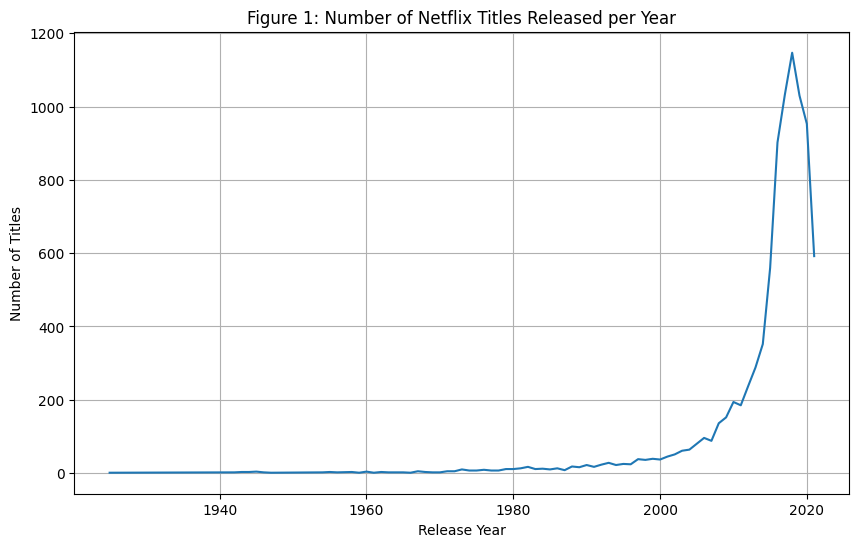

In [79]:
# group and count titles by release year
titles_per_year = df.groupby('release_year')['title'].count().reset_index()

# plot
plt.figure(figsize=(10,6))
plt.plot(titles_per_year['release_year'], titles_per_year['title']) # x and y axis
plt.title('Figure 1: Number of Netflix Titles Released per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.grid()
plt.show()

#### Visualization 2: 

Our second and third visualizations have to do with the duration of Netflix content, namely analyzing how long movies and TV shows typically run for. Figure 2 below shows the distribution of movie durations, showing that most Netflix movies are between 80 and 120 minutes long, which is quite typical with feature film lengths. Only a few movies exceed 150 minutes, indicating that very long films are rare on the platform. This visualization helps us understand Netflix’s focus on engaging content which most people prefer.

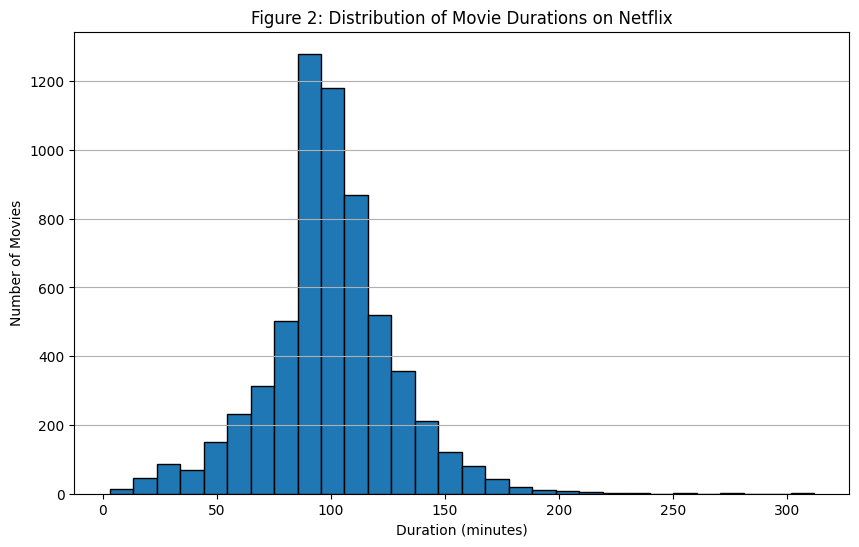

In [80]:
# extract numeric duration
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float) 

# separate movies and TV shows
movies = df[df['type'] == 'Movie']
tv_shows = df[df['type'] == 'TV Show']

# plot histogram
plt.figure(figsize=(10,6))
plt.hist(movies['duration_num'],
    bins=30,  
    edgecolor='black'
)
plt.title('Figure 2: Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.grid(axis='y')
plt.show()

#### Visualization 3: 

Figure 3 is a graph that illustrates the distribution of TV show seasons on Netflix. It shows that the majority of shows have only one or two seasons, with the number of titles sharply decreasing as the season count increases. This indicates that Netflix primarily focuses on producing limited series or shorter shows and when a show is sucessful, there will be more seasons created of it.

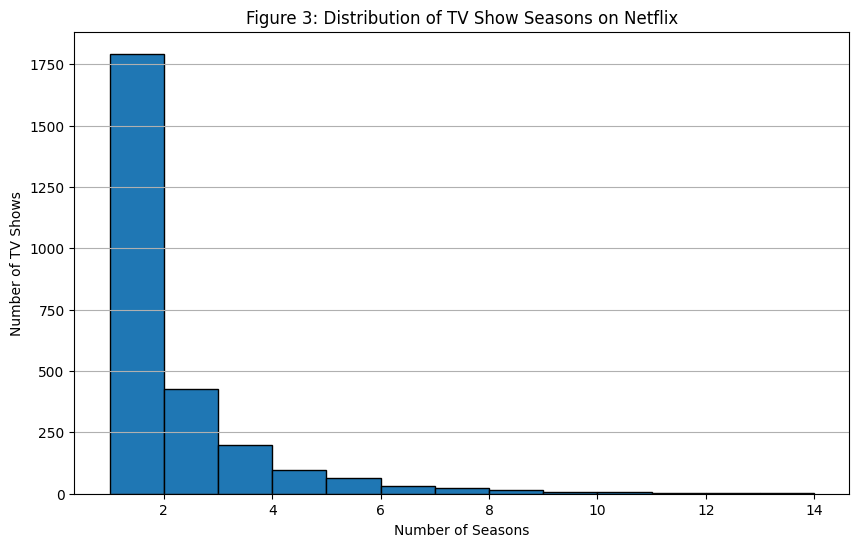

In [81]:
# plot histogram for TV shows
plt.figure(figsize=(10,6))
plt.hist(
    tv_shows['duration_num'],
    bins=range(1,15),
    edgecolor='black'
)
plt.title('Figure 3: Distribution of TV Show Seasons on Netflix')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')
plt.grid(axis='y')
plt.show()

When exploring the Netflix dataset, my visualizations were shaped by assumptions about how time, categories, and relationships work in the data. For example, comparing TV shows vs. movies assumes the type column is reliable and complete. When analyzing seasons, I assumed the duration field is consistent for all shows and for movie lengths, I assumed the minutes listed are accurate. These assumptions affect how confidently patterns can be interpreted. Also, the dataset’s structure also influenced my EDA: it is a flat table with mostly categorical and numerical fields, which makes grouping and counting simple but limits deeper relational analysis.

### 2.3 Machine Learning Component (Bonus)
#### 2.3.1 Problem Definition

Based on the structure of the data (a highly structured tabular dataset), database used (document database) and the relationships in our database, for our classification task, our goal is to predict whether any given Netflix title chose at random from the dataset is a Movie or a TV Show. We will try to predict this using the features in the dataset such as release year, duration, director and more. In order to perform this task, I used a Logistic Regression model, which is a very popular algorithm used for classification problems. It works by calculating the probability that a certain objcet belongs to a TV Show or Movie. It is a model that is usually very fast to train and realiable in testing.

#### 2.3.2 Feature Engineering

The way we design and store features in our dataset has a big impact on how well a machine learning model and the database work. Good feature design like using clean, meaningful, and properly encoded data helps the model learn faster and make more accurate predictions in the end. For example, changing text categories into numbers (encoding) makes it easier for the model to understand patterns between different categories. When it comes to storing data efficiently, it is in the best practice to remove duplicates, reducing and simplifying unnecessary columns, and using numeric data instead of long text makes the database smaller, faster, and easier to process. For document databases, feature engineering is especially useful because each movie or show is stored as its own flexible JSON document. This means we can design features in a way that keeps each document consistent and easy to query. 

#### 2.3.3 Model Choice and Justification

Based on the structure of the data, (tabular dataset with well-defined columns) as well as the relationships represented in our database we selected a classification task to predict whether any given Netflix title is a Movie or a TV Show. To accomplish this, we used a Logistic Regression model, a widely adopted algorithm for binary classification that estimates the probability of an instance in a dataset belonging to each class. Logistic Regression is computationally efficient and provides a strong baseline for understanding which features have the greatest influence on predicted outcome.

#### 2.3.4 Model Evaluation

Below is the code, accuracy score and results table for the Machine Leaning Model which uses Logsitic Regression. We find that the model performs extremely well, achieving an accuracy of 99%. Both categories of Movies and TV Shows have very high precision, recall, and F1-scores, meaning the model correctly identifies nearly all titles without too many mistakes. This shows that the selected features, such as release year, duration etc. are highly effective in distinguishing between movies and TV shows. The strong performance also shows that the Logistic Regression model chosen was a suitable choice for this binary classification task.

For our document database, the model’s strong results also reflect the quality of the ingestion pipeline, since cleaning missing values and loading well-structured JSON documents ensured the features were reliable. Because real-world data like Netflix titles is often messy and uneven, the document model helped keep this flexibility while still allowing us to extract clean features for modeling.

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression

df = df.copy()

# count genres per title
df['num_genres']  = df['listed_in'].fillna('').astype(str).apply(
    lambda s: len([g for g in s.split(',') if g.strip()])
)

# target: Movie=1, TV Show=0
y = df['type'].map({'Movie': 1, 'TV Show': 0})

# feature Engineering: numeric + one-hot rating 
X = pd.concat([
    df[['release_year', 'duration_num', 'num_genres']],
    pd.get_dummies(df['rating'].fillna('Unknown'), prefix='rating')
], axis=1).fillna(0)

# train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = LogisticRegression()
model.fit(X_train, y_train)

# show results
y_pred = model.predict(X_test)

print(f"Accuracy (%): {accuracy_score(y_test, y_pred) * 100:.1f}%")
print(classification_report(y_test, y_pred, target_names=['TV Show', 'Movie']))

Accuracy (%): 99.7%
              precision    recall  f1-score   support

     TV Show       0.99      1.00      1.00       535
       Movie       1.00      1.00      1.00      1227

    accuracy                           1.00      1762
   macro avg       1.00      1.00      1.00      1762
weighted avg       1.00      1.00      1.00      1762

